In [12]:
import os
import gzip
import json
import collections
import pandas as pd
import subprocess
import shutil
import sys
import bisect

# -----------------------
# Configuration
# -----------------------
TEST_SAMPLES_CSV = "testing_complete_processed_padding_metadata.csv"
THRESHOLDS_JSON = "training_results_seed_67/best_thresholds.json"
OUT_DIR = "testing_padding_results"
EXOME_BED_PATH = "../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed" 

# Paths to your blacklists (Make sure these match your filenames!)
BLACKLIST_BED = "../../resources/master_blacklist.bed"  
ARTEFACT_GENES_BED = "../../resources/master_blacklist.bed" 

# Constants
GENOME_SIZE = 6.4e9
R_CORD = 2e-8
PADDING_SIZE = 135  # The size of your padding window in base pairs

# -----------------------
# BED Lookup Logic
# -----------------------
class BedLookup:
    def __init__(self, bed_path, name):
        self.intervals = {} 
        self.name = name
        self._load_bed(bed_path)

    def _load_bed(self, bed_path):
        if not os.path.exists(bed_path):
            print(f"[WARN] BED file not found: {bed_path}. {self.name} filter will do nothing.", file=sys.stderr)
            return

        print(f"[INFO] Loading {self.name} from {bed_path}...")
        count = 0
        with open(bed_path, 'r') as f:
            for line in f:
                if line.startswith('#') or not line.strip():
                    continue
                parts = line.strip().split()
                if len(parts) < 3:
                    continue
                chrom = parts[0]
                start, end = int(parts[1]), int(parts[2])
                
                if chrom not in self.intervals:
                    self.intervals[chrom] = []
                self.intervals[chrom].append((start, end))
                count += 1
        
        # Sort intervals for binary search
        for chrom in self.intervals:
            self.intervals[chrom].sort(key=lambda x: x[0])
        print(f"[INFO] Loaded {count} regions for {self.name}.")

    def _get_regions(self, chrom):
        if chrom in self.intervals:
            return self.intervals[chrom]
        elif f"chr{chrom}" in self.intervals:
            return self.intervals[f"chr{chrom}"]
        elif chrom.startswith("chr") and chrom[3:] in self.intervals:
            return self.intervals[chrom[3:]]
        return None

    def is_overlapped(self, chrom, pos):
        regions = self._get_regions(chrom)
        if not regions: return False
        
        query_idx = pos - 1 
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))
        
        for i in range(max(0, idx - 1), -1, -1):
            start, end = regions[i]
            if end <= query_idx: break 
            if start <= query_idx < end: return True
        return False

    def get_overlap_status(self, chrom, pos, padding=PADDING_SIZE):
        """
        Determines if a position is strictly in 'WES', in 'PADDING', or 'NONE'.
        Strict WES overlap takes precedence over adjacent padding.
        """
        regions = self._get_regions(chrom)
        if not regions: return "NONE"

        query_idx = pos - 1
        idx = bisect.bisect_right(regions, (query_idx, float('inf')))

        is_padding = False

        # 1. Check interval strictly to the left
        if idx > 0:
            left_start, left_end = regions[idx - 1]
            if left_start <= query_idx < left_end:
                return "WES"
            if left_end <= query_idx < left_end + padding:
                is_padding = True

        # 2. Check interval starting immediately after/at query_idx
        if idx < len(regions):
            right_start, right_end = regions[idx]
            if right_start <= query_idx < right_end: # Extra safeguard
                return "WES"
            if right_start - padding <= query_idx < right_start:
                is_padding = True

        if is_padding:
            return "PADDING"
        
        return "NONE"


# -----------------------
# Helper Functions
# -----------------------
def safe_float(x, default=0.0):
    try: return float(x)
    except (ValueError, TypeError): return default

def safe_int(x, default=0):
    try: return int(float(x))
    except (ValueError, TypeError): return default

def parse_info(info_str):
    info_dict = {}
    if not info_str or info_str == ".": return info_dict
    for item in info_str.split(";"):
        if "=" in item:
            k, v = item.split("=", 1)
            info_dict[k] = v
        else:
            info_dict[item] = "Yes"
    return info_dict

def check_dependencies():
    return shutil.which("bgzip") is not None and shutil.which("tabix") is not None

def get_expected_rate(sample_type, age):
    st = sample_type.lower()
    age = float(age) if pd.notna(age) else 0.0
    if "cord" in st:
        return R_CORD
    elif "pbmc" in st:
        return (16 * age + 105) / GENOME_SIZE
    else:
        return (22 * age + 164) / GENOME_SIZE

# -----------------------
# Filtering Logic
# -----------------------
def apply_filters(info, thresholds, pon_flags):
    # [Unchanged: Copy your exact filtering logic here]
    n_total_dcs = safe_int(info.get("N_TOTAL", 0))
    n_total_sscs = safe_int(info.get("N_TOTAL_SSCS", n_total_dcs))
    if n_total_sscs <= 0: n_total_sscs = n_total_dcs
    n_alt_sscs = safe_int(info.get("N_ALT_SSCS", 0))

    asxs = safe_float(info.get("AVG_ALT_ASXS", 0.0))
    mean_mapq = safe_float(info.get("MEAN_ALT_MAPQ", 0.0))
    mean_baseq = safe_float(info.get("MEAN_ALT_BASEQ", 0.0))
    dist_to_indel = safe_int(info.get("DIST_TO_INDEL", -1))
    homopolymer_len = safe_int(info.get("HOMOPOLYMER_LEN", 0))
    strand_bias = safe_float(info.get("STRAND_BIAS_SSCS", 0.5))
    rp_sd = safe_float(info.get("RP_SD_SSCS", 0.0))
    rp_med = safe_float(info.get("RP_MED_SSCS", 0.5))
    depth_percentile = safe_int(info.get("DP_PERCENT", 50))
    avg_read_pos = safe_float(info.get("AVG_READ_POSITION", 75.0))
    
    variants_20bp = safe_int(info.get("VARIANTS_20BP", 0))
    variants_250bp = safe_int(info.get("VARIANTS_250BP", 0))
    median_dist_softclip = safe_int(info.get("MEDIAN_DIST_TO_SOFTCLIP", 1000))
    avg_alt_softclip = safe_float(info.get("AVG_ALT_SOFTCLIP", 0.0))
    avg_alt_n_count = safe_float(info.get("AVG_ALT_N_COUNT", 0.0))
    avg_alt_nm = safe_float(info.get("AVG_ALT_NM", 0.0))
    mean_insert = safe_float(info.get("MEAN_INSERT", 200.0))
    
    sd_baseq = safe_float(info.get("SD_ALT_BASEQ", 0.0))
    mean_ref_mapq = safe_float(info.get("MEAN_REF_MAPQ", 0.0))

    in_cord_pon = info.get("IN_CB_PON", "No")
    in_gnomad = info.get("IN_GNOMAD_COMMON", "No")
    in_encode = info.get("IN_ENCODE_BLACKLIST", "No")
    in_repeatmasker = info.get("IN_REPEATMASKER", "No")

    vaf_sscs = n_alt_sscs / n_total_sscs if n_total_sscs > 0 else 0.0

    if n_alt_sscs <= 0: return False, "HARD_N_ALT_SSCS"
    if in_encode == "Yes": return False, "HARD_ENCODE_BLACKLIST"
    if in_repeatmasker == "Yes": return False, "HARD_REPEATMASKER"
    if avg_read_pos < 4 or avg_read_pos > 138: return False, "HARD_READ_POS_EDGE"

    if pon_flags.get("use_cord_pon", False) and in_cord_pon == "Yes": return False, "FAIL_CORD_PON"

    if n_total_dcs < thresholds["n_total_min"]: return False, "FAIL_MIN_DEPTH"
    if depth_percentile > thresholds["depth_percentile_max"]: return False, "FAIL_DEPTH_PERCENTILE"
    if asxs < thresholds["asxs_min"]: return False, "FAIL_ASXS"
    if mean_mapq < thresholds["mean_mapq_min"]: return False, "FAIL_MAPQ"
    if mean_baseq < thresholds["mean_baseq_min"]: return False, "FAIL_BASEQ"
    if dist_to_indel != -1 and dist_to_indel < thresholds["dist_to_indel_min"]: return False, "FAIL_DIST_TO_INDEL"
    if variants_20bp > thresholds["variants_20bp_max"]: return False, "FAIL_VARIANTS_20BP"
    if variants_250bp > thresholds["variants_250bp_max"]: return False, "FAIL_VARIANTS_250BP"
    if avg_alt_softclip > thresholds["avg_alt_softclip_max"]: return False, "FAIL_AVG_ALT_SOFTCLIP"
    if median_dist_softclip < thresholds["dist_to_softclip_min"]: return False, "FAIL_DIST_TO_SOFTCLIP"
    if avg_alt_n_count > thresholds["avg_alt_n_count_max"]: return False, "FAIL_AVG_ALT_N_COUNT"
    if avg_alt_nm > thresholds["avg_alt_nm_max"]: return False, "FAIL_AVG_ALT_NM"
    if mean_insert > thresholds["mean_insert_max"]: return False, "FAIL_MEAN_INSERT"
    if homopolymer_len > thresholds["homopolymer_len_max"]: return False, "FAIL_HOMOPOLYMER"

    if n_alt_sscs >= thresholds["strand_bias_n_alt_min"]:
        if strand_bias < thresholds["strand_bias_min"] or strand_bias > thresholds["strand_bias_max"]:
            return False, "FAIL_STRAND_BIAS"
        
    if sd_baseq > thresholds["sd_baseq_max"]: return False, "FAIL_SD_BASEQ"
    if mean_ref_mapq < thresholds["mean_ref_mapq_min"]: return False, "FAIL_MEAN_REF_MAPQ"

    if n_alt_sscs >= thresholds["rp_sd_min_alt"]:
        if rp_sd < thresholds["rp_sd_min"]: return False, "FAIL_RP_SD"
    if rp_med < thresholds["rp_med_min"] or rp_med > thresholds["rp_med_max"]: return False, "FAIL_RP_MED"

    if vaf_sscs > thresholds["germline_vaf_max"]: return False, "FAIL_GERMLINE_VAF"
    if (vaf_sscs > thresholds["gnomad_vaf_cutoff"]) and (in_gnomad == "Yes"):
        return False, "FAIL_GNOMAD_COMMON"

    return True, None

# -----------------------
# Main Execution
# -----------------------
os.makedirs(OUT_DIR, exist_ok=True)
has_htslib = check_dependencies()

print("[INFO] Initializing Exome Target and Blacklists...")
exome_lookup = BedLookup(EXOME_BED_PATH, "Exome Targets") 
cluster_lookup = BedLookup(BLACKLIST_BED, "Cluster Blacklist")
artefact_lookup = BedLookup(ARTEFACT_GENES_BED, "Artefact Gene Blacklist")

if not os.path.exists(THRESHOLDS_JSON):
    print(f"[ERROR] Thresholds file not found: {THRESHOLDS_JSON}")
else:
    with open(THRESHOLDS_JSON) as f:
        data = json.load(f)
        thresholds = data["thresholds"]
        pon_flags = data.get("pon_flags", {})
    print("[INFO] Thresholds loaded.")

    if not os.path.exists(TEST_SAMPLES_CSV):
         print(f"[ERROR] Test samples CSV not found: {TEST_SAMPLES_CSV}")
    else:
        df_samples = pd.read_csv(TEST_SAMPLES_CSV)
        print(f"[INFO] Processing {len(df_samples)} test samples...")

        results_data = []
        all_fail_reasons = []

        for idx, s in df_samples.iterrows():
            print(f"  -> {s.sample_id}", end="\r")
            
            input_basename = os.path.basename(s.vcf_path).replace(".vcf", "").replace(".gz", "")
            
            # Create two discrete output paths
            out_vcf_wes = os.path.join(OUT_DIR, f"{s.sample_id}_{input_basename}_WES.filtered.vcf")
            out_vcf_pad = os.path.join(OUT_DIR, f"{s.sample_id}_{input_basename}_PADDING.filtered.vcf")
            
            if not os.path.exists(s.vcf_path):
                print(f"\n[WARN] VCF not found: {s.vcf_path}")
                continue

            openf = gzip.open if s.vcf_path.endswith(".gz") else open
            n_pass_wes = 0
            n_pass_pad = 0
            
            try:
                # Open input and BOTH output files simultaneously
                with openf(s.vcf_path, "rt") as fin, \
                     open(out_vcf_wes, "w") as fw_wes, \
                     open(out_vcf_pad, "w") as fw_pad:
                    
                    for line in fin:
                        if line.startswith("#"):
                            fw_wes.write(line)
                            fw_pad.write(line)
                            continue
                        
                        fields = line.strip().split("\t")
                        if len(fields) < 8: continue
                        
                        chrom = fields[0]
                        pos = int(fields[1])
                        
                        # NEW: Use get_overlap_status to determine exact tier
                        target_status = exome_lookup.get_overlap_status(chrom, pos, padding=PADDING_SIZE)
                        
                        if target_status == "NONE":
                            all_fail_reasons.append("FAIL_NOT_IN_EXOME_OR_PADDING")
                            continue 
                        
                        if cluster_lookup.is_overlapped(chrom, pos):
                            all_fail_reasons.append("FAIL_CLUSTER_BLACKLIST")
                            continue 
                        
                        if artefact_lookup.is_overlapped(chrom, pos):
                            all_fail_reasons.append("FAIL_ARTEFACT_BLACKLIST")
                            continue 
                        
                        info = parse_info(fields[7])
                        passed, reason = apply_filters(info, thresholds, pon_flags)
                        
                        if passed:
                            if target_status == "WES":
                                n_pass_wes += 1
                                fw_wes.write(line)
                            elif target_status == "PADDING":
                                n_pass_pad += 1
                                fw_pad.write(line)
                        else:
                            all_fail_reasons.append(reason)
            except Exception as e:
                print(f"\n[ERROR] Failed on {s.sample_id}: {e}")
                continue

            # Compress and Index BOTH outputs
            if has_htslib:
                for out_file in [out_vcf_wes, out_vcf_pad]:
                    try:
                        subprocess.run(["bgzip", "-f", out_file], check=True, stderr=subprocess.DEVNULL)
                        subprocess.run(["tabix", "-p", "vcf", out_file + ".gz"], check=True, stderr=subprocess.DEVNULL)
                    except:
                        pass
            
            # Calculate Bases correctly
            sample_type = s.get("sample_type", "T_cells")
            age = safe_float(s.get("age", 0.0))
            
            bases_wes = safe_float(s.get("total_callable_bases_in_wes", 0.0))
            # Assuming your CSV column is literally called 'total_callable_bases_padding'
            bases_total_pad_col = safe_float(s.get("total_callable_bases_in_padded_wes", 0.0))
            bases_pad = max(0.0, bases_total_pad_col - bases_wes) 
            
            exp_rate = get_expected_rate(sample_type, age)
            
            results_data.append({
                "sample_id": s.sample_id,
                "sample_type": sample_type,
                "age": age,
                "bases_wes": bases_wes,
                "bases_padding": bases_pad,
                "observed_wes": n_pass_wes,
                "observed_padding": n_pass_pad,
                "expected_wes": exp_rate * bases_wes,
                "expected_padding": exp_rate * bases_pad
            })

        print("\n[INFO] Filtering complete.")

        res_df = pd.DataFrame(results_data)
        res_df.to_csv(os.path.join(OUT_DIR, "test_summary.csv"), index=False)
        
        reason_counts = collections.Counter(all_fail_reasons)
        fail_df = pd.DataFrame(reason_counts.items(), columns=["Reason", "Count"]).sort_values("Count", ascending=False)
        fail_df.to_csv(os.path.join(OUT_DIR, "filter_failure_counts.csv"), index=False)

        print("-" * 30)
        print(f"Results saved to: {OUT_DIR}")
        print("-" * 30)

[INFO] Initializing Exome Target and Blacklists...
[INFO] Loading Exome Targets from ../../resources/hg38_exome_v2.0.2_targets_sorted_validated.re_annotated.bed...
[INFO] Loaded 283942 regions for Exome Targets.
[INFO] Loading Cluster Blacklist from ../../resources/master_blacklist.bed...
[INFO] Loaded 4208652 regions for Cluster Blacklist.
[INFO] Loading Artefact Gene Blacklist from ../../resources/master_blacklist.bed...
[INFO] Loaded 4208652 regions for Artefact Gene Blacklist.
[INFO] Thresholds loaded.
[INFO] Processing 18 test samples...
  -> CUH832_TILS_CD8
[INFO] Filtering complete.
------------------------------
Results saved to: testing_padding_results
------------------------------


----------------------------------------
Generating WES Plot...
----------------------------------------
[INFO] Observed vs Expected SNV Rate (Test Set - WES Only) - Poisson Deviance: 1834.9558
[INFO] Plot saved to: testing_results/test_observed_vs_expected_plot_WES.png



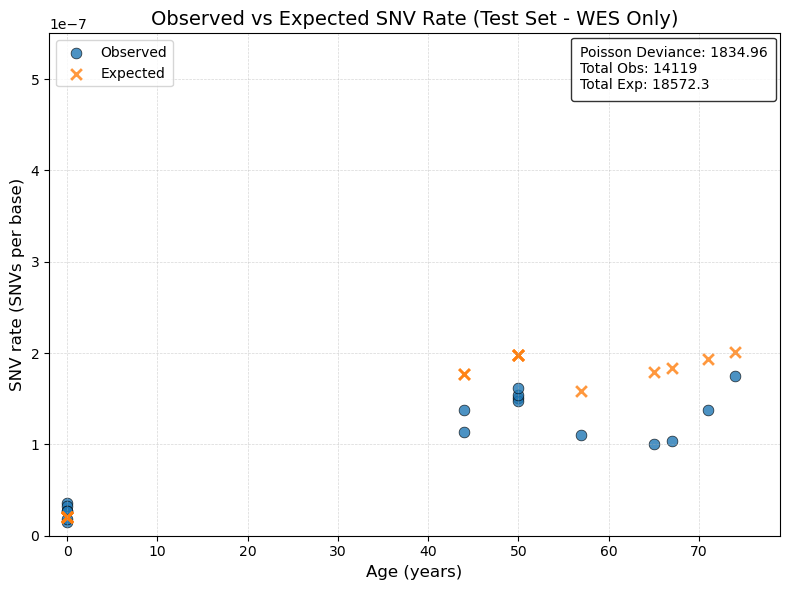

----------------------------------------
Generating Padding Plot...
----------------------------------------
[INFO] Observed vs Expected SNV Rate (Test Set - PADDING Only) - Poisson Deviance: 935.7251
[INFO] Plot saved to: testing_results/test_observed_vs_expected_plot_PADDING.png



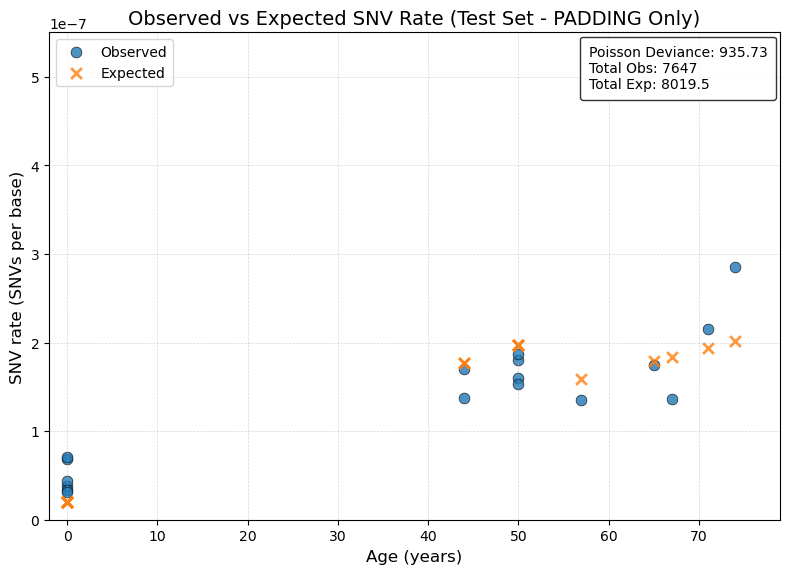

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from matplotlib.offsetbox import AnchoredText

# -----------------------
# Configuration
# -----------------------
CSV_PATH = "testing_padding_results/test_summary.csv"
OUTPUT_PNG_WES = "testing_results/test_observed_vs_expected_plot_WES.png"
OUTPUT_PNG_PAD = "testing_results/test_observed_vs_expected_plot_PADDING.png"
EPS = 1e-15

# -----------------------
# Helper Functions
# -----------------------
def poisson_deviance(y_arr, lam_arr):
    """
    Calculates Poisson Deviance between observed (y) and expected (lambda).
    Formula: 2 * sum( y * log(y / lambda) - (y - lambda) )
    """
    y = np.asarray(y_arr, dtype=float)
    lam = np.asarray(lam_arr, dtype=float) + EPS
    
    with np.errstate(divide='ignore', invalid='ignore'):
        log_term = np.log(y / lam)
        term1 = np.where(y > 0, y * log_term, 0.0)
    
    dev = 2.0 * (term1 - (y - lam))
    return float(np.sum(dev))

def generate_rate_plot(title, ages, bases, observed, expected, output_path):
    """
    Generates and saves the Observed vs Expected SNV rate plot.
    """
    # Calculate SNV rates per base
    # (Using np.divide to handle cases where bases might be 0)
    obs_rate = np.divide(observed, bases, out=np.zeros_like(observed, dtype=float), where=bases!=0)
    exp_rate = np.divide(expected, bases, out=np.zeros_like(expected, dtype=float), where=bases!=0)

    # Calculate Deviance and Totals
    deviance = poisson_deviance(observed, expected)
    total_obs = np.sum(observed)
    total_exp = np.sum(expected)

    # Plotting
    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot Observed (Blue circles)
    ax.scatter(ages, obs_rate, label="Observed", color="#1f77b4", alpha=0.8, marker="o", s=60, edgecolors='k', linewidth=0.5)

    # Plot Expected (Orange crosses)
    ax.scatter(ages, exp_rate, label="Expected", color="#ff7f0e", alpha=0.8, marker="x", s=60, linewidth=2)

    # Styling
    ax.set_xlabel("Age (years)", fontsize=12)
    ax.set_ylabel("SNV rate (SNVs per base)", fontsize=12)
    
    # Handle X-limits (pad slightly around min/max age)
    valid_ages = ages[~np.isnan(ages)]
    if len(valid_ages) > 0:
        ax.set_xlim(min(valid_ages) - 2, max(valid_ages) + 5)
    else:
        ax.set_xlim(-2, 100)

    # Hardcoded Y-limits (Same as training plot for consistency)
    ax.set_ylim(0, 5.5e-7)
    
    ax.set_title(title, fontsize=14)
    ax.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.5)
    
    # Add Stats Box (Deviance)
    stats_text = (f"Poisson Deviance: {deviance:.2f}\n"
                  f"Total Obs: {int(total_obs)}\n"
                  f"Total Exp: {total_exp:.1f}")
    
    at = AnchoredText(stats_text, prop=dict(size=10), frameon=True, loc='upper right')
    at.patch.set_boxstyle("round,pad=0.2,rounding_size=0.2")
    at.patch.set_alpha(0.8)
    ax.add_artist(at)

    # Legend
    ax.legend(loc='upper left', frameon=True, fontsize=10)

    plt.tight_layout()
    
    # Save and Show
    plt.savefig(output_path, dpi=150)
    print(f"[INFO] {title} - Poisson Deviance: {deviance:.4f}")
    print(f"[INFO] Plot saved to: {output_path}\n")
    plt.show()

# -----------------------
# Main Execution
# -----------------------
if not os.path.exists(CSV_PATH):
    print(f"[ERROR] Could not find {CSV_PATH}. Please run the test filtering step first.")
else:
    # Load table
    df = pd.read_csv(CSV_PATH)
    ages = df["age"].values

    print("-" * 40)
    print("Generating WES Plot...")
    print("-" * 40)
    generate_rate_plot(
        title="Observed vs Expected SNV Rate (Test Set - WES Only)",
        ages=ages,
        bases=df["bases_wes"].values,
        observed=df["observed_wes"].values,
        expected=df["expected_wes"].values,
        output_path=OUTPUT_PNG_WES
    )

    print("-" * 40)
    print("Generating Padding Plot...")
    print("-" * 40)
    generate_rate_plot(
        title="Observed vs Expected SNV Rate (Test Set - PADDING Only)",
        ages=ages,
        bases=df["bases_padding"].values,
        observed=df["observed_padding"].values,
        expected=df["expected_padding"].values,
        output_path=OUTPUT_PNG_PAD
    )

----------------------------------------
Generating WES Comparison Plot...
----------------------------------------
[INFO] Train Cord Rate: 3.09e-08 (Obs: 644)
[INFO] Test Cord Rate:  2.79e-08 (Obs: 1228)
[INFO] Reference Rate:  2.00e-08
[INFO] Plot saved to: ./cord_blood_snv_comparison_WES.png



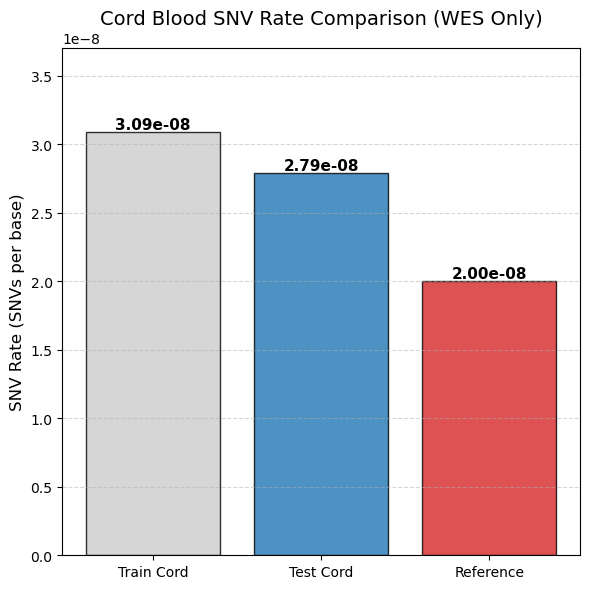

----------------------------------------
Generating PADDING Comparison Plot...
----------------------------------------
[INFO] Train Cord Rate: 6.20e-08 (Obs: 491)
[INFO] Test Cord Rate:  5.06e-08 (Obs: 919)
[INFO] Reference Rate:  2.00e-08
[INFO] Plot saved to: ./cord_blood_snv_comparison_PADDING.png



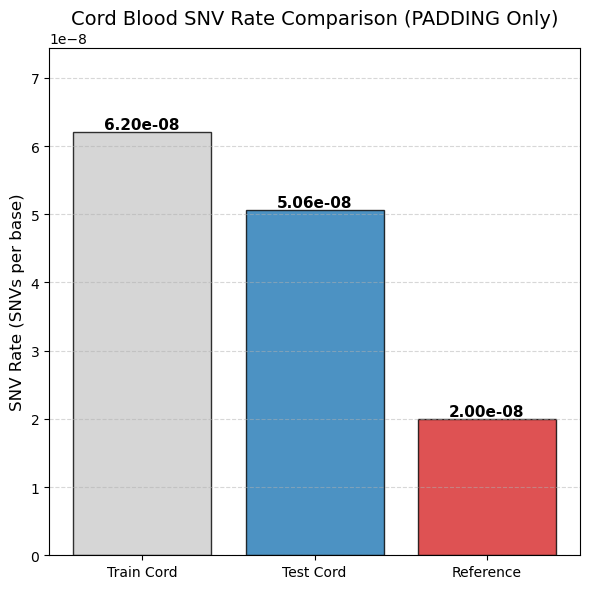

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# -----------------------
# Configuration
# -----------------------
TRAIN_CSV = "training_padding_results/test_summary.csv"
TEST_CSV = "testing_padding_results/test_summary.csv"

# Output Paths
OUTPUT_PNG_WES = "./cord_blood_snv_comparison_WES.png"
OUTPUT_PNG_PAD = "./cord_blood_snv_comparison_PADDING.png"

REFERENCE_RATE = 2e-8

# -----------------------
# Helper Functions
# -----------------------
def get_cord_blood_rate(csv_path, obs_col="observed", bases_col="bases"):
    """
    Loads CSV, filters for age == 0 (Cord Blood), 
    and calculates aggregate SNV rate based on target columns.
    """
    if not os.path.exists(csv_path):
        print(f"[WARNING] File not found: {csv_path}")
        return 0.0, 0
        
    df = pd.read_csv(csv_path)
    
    # Filter for Cord Blood (Age = 0)
    cord_data = df[np.isclose(df["age"], 0, atol=1e-5)]
    
    if cord_data.empty:
        print(f"[WARNING] No Cord Blood (age=0) data found in {csv_path}")
        return 0.0, 0
    
    # Fallback to standard columns if WES/PADDING split hasn't been run on this CSV yet
    if obs_col not in df.columns:
        print(f"[WARNING] '{obs_col}' not in {os.path.basename(csv_path)}, falling back to 'observed'")
        obs_col = "observed"
    if bases_col not in df.columns:
        print(f"[WARNING] '{bases_col}' not in {os.path.basename(csv_path)}, falling back to 'bases'")
        bases_col = "bases"
        
    # Prevent KeyError if even the fallback is missing
    if obs_col not in df.columns or bases_col not in df.columns:
         print(f"[ERROR] Could not find valid count/base columns in {csv_path}")
         return 0.0, 0

    total_obs = cord_data[obs_col].sum()
    total_bases = cord_data[bases_col].sum()
    
    if total_bases == 0:
        return 0.0, 0
        
    return total_obs / total_bases, total_obs

def plot_cord_blood_comparison(title, train_rate, test_rate, train_obs, test_obs, output_path):
    """
    Generates and saves the bar chart comparing Cord Blood SNV rates.
    """
    labels = ['Train Cord', 'Test Cord', 'Reference']
    rates = [train_rate, test_rate, REFERENCE_RATE]
    colors = ['#cccccc', '#1f77b4', '#d62728']  # Grey, Blue, Red

    fig, ax = plt.subplots(figsize=(6, 6))

    bars = ax.bar(labels, rates, color=colors, edgecolor='k', alpha=0.8)

    ax.set_ylabel("SNV Rate (SNVs per base)", fontsize=12)
    ax.set_title(title, fontsize=14)
    ax.grid(axis='y', linestyle='--', alpha=0.5)

    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.2e}',
                ha='center', va='bottom', fontsize=11, fontweight='bold')

    ax.set_ylim(0, max(rates) * 1.2 if max(rates) > 0 else REFERENCE_RATE * 1.2)

    plt.tight_layout()

    plt.savefig(output_path, dpi=150)
    print(f"[INFO] Train Cord Rate: {train_rate:.2e} (Obs: {int(train_obs)})")
    print(f"[INFO] Test Cord Rate:  {test_rate:.2e} (Obs: {int(test_obs)})")
    print(f"[INFO] Reference Rate:  {REFERENCE_RATE:.2e}")
    print(f"[INFO] Plot saved to: {output_path}\n")
    plt.show()

# -----------------------
# Main Execution
# -----------------------

# --- 1. WES Analysis ---
print("-" * 40)
print("Generating WES Comparison Plot...")
print("-" * 40)
train_rate_wes, train_obs_wes = get_cord_blood_rate(TRAIN_CSV, obs_col="observed_wes", bases_col="bases_wes")
test_rate_wes, test_obs_wes = get_cord_blood_rate(TEST_CSV, obs_col="observed_wes", bases_col="bases_wes")

plot_cord_blood_comparison(
    title="Cord Blood SNV Rate Comparison (WES Only)",
    train_rate=train_rate_wes,
    test_rate=test_rate_wes,
    train_obs=train_obs_wes,
    test_obs=test_obs_wes,
    output_path=OUTPUT_PNG_WES
)

# --- 2. PADDING Analysis ---
print("-" * 40)
print("Generating PADDING Comparison Plot...")
print("-" * 40)
train_rate_pad, train_obs_pad = get_cord_blood_rate(TRAIN_CSV, obs_col="observed_padding", bases_col="bases_padding")
test_rate_pad, test_obs_pad = get_cord_blood_rate(TEST_CSV, obs_col="observed_padding", bases_col="bases_padding")

plot_cord_blood_comparison(
    title="Cord Blood SNV Rate Comparison (PADDING Only)",
    train_rate=train_rate_pad,
    test_rate=test_rate_pad,
    train_obs=train_obs_pad,
    test_obs=test_obs_pad,
    output_path=OUTPUT_PNG_PAD
)